#### Name: Rujuta Bhanose
#### Email ID: rujuta.22311432@viit.ac.in
#### Contact No: 8421279093

# Trader Performance vs Market Sentiment — EDA

**Objective:** Explore the relationship between crypto trader performance and market sentiment (Fear & Greed Index), uncover hidden behavioural patterns, and derive insights that can inform smarter trading strategies.

**Datasets:**
- `fear_greed_index.csv` — 2,644 daily sentiment readings from Feb 2018 to May 2025
- `historical_data.csv` — 211,224 trades across 32 unique traders on a crypto perpetuals platform

**Approach:** We merge both datasets on date, then systematically analyse how PnL, win rate, trade size, and position direction vary across sentiment regimes — followed by trader-level profiling and archetype classification.

## 1. Setup & data loading

Load both datasets, parse dates, and merge on the daily Fear & Greed score. We also engineer key columns used throughout the analysis: `position_type` (Long/Short), `is_win` (PnL > 0), `fg_bucket` (score binned into ranges), and `month`.

In [40]:
import pandas as pd
import numpy as np

In [41]:
# Load Data
fg = pd.read_csv('fear_greed_index.csv')
hd = pd.read_csv('historical_data.csv')

In [42]:
# Parse Dates
fg['date'] = pd.to_datetime(fg['date'])
hd['date'] = pd.to_datetime(hd['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.normalize()

In [43]:
# Merge on date
df = hd.merge(fg[['date', 'value', 'classification']], on='date', how='left')
print("Merge coverage (% trades matched to F&G date):",
      round(df['value'].notna().mean() * 100, 2), "%")
print("Date range in trades:", df['date'].min(), "→", df['date'].max())
print()

Merge coverage (% trades matched to F&G date): 100.0 %
Date range in trades: 2023-05-01 00:00:00 → 2025-05-01 00:00:00



## 2. Sentiment-level analysis

How does trader performance vary across the five sentiment regimes — Extreme Fear, Fear, Neutral, Greed, and Extreme Greed?

We look at:
- Trade volume distribution across regimes
- Average and median Closed PnL per regime
- Average trade size per regime
- Buy/Sell ratio per regime
- Win rate per regime

In [44]:
# Sentiment distribution
print("=== 1. Sentiment distribution (trade count) ===")
sent_dist = df.groupby('classification').size().sort_values(ascending=False)
print(sent_dist)
print()

=== 1. Sentiment distribution (trade count) ===
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
dtype: int64



In [45]:
# PnL by sentiment
print("=== 2. Avg & Median Closed PnL by sentiment ===")
pnl_sent = df.groupby('classification')['Closed PnL'].agg(['mean', 'median', 'std', 'count'])
print(pnl_sent.sort_values('mean', ascending=False))
print()

=== 2. Avg & Median Closed PnL by sentiment ===
                     mean  median          std  count
classification                                       
Extreme Greed   67.892861     0.0   766.828294  39992
Fear            54.290400     0.0   935.355438  61837
Greed           42.743559     0.0  1116.028390  50303
Extreme Fear    34.537862     0.0  1136.056091  21400
Neutral         34.307718     0.0   517.122220  37686



In [46]:
# Trade volume (Size USD) by sentiment
print("=== 3. Avg trade size (USD) by sentiment ===")
size_sent = df.groupby('classification')['Size USD'].agg(['mean', 'median'])
print(size_sent)
print()

=== 3. Avg trade size (USD) by sentiment ===
                       mean   median
classification                      
Extreme Fear    5349.731843  766.150
Extreme Greed   3112.251565  500.050
Fear            7816.109931  735.960
Greed           5736.884375  555.000
Neutral         4782.732661  547.655



In [47]:
# Buy vs Sell ratio by sentiment
print("=== 4. Buy/Sell ratio by sentiment ===")
side_sent = df.groupby(['classification', 'Side']).size().unstack(fill_value=0)
side_sent['buy_ratio'] = side_sent['BUY'] / (side_sent['BUY'] + side_sent['SELL'])
print(side_sent)
print()

=== 4. Buy/Sell ratio by sentiment ===
Side              BUY   SELL  buy_ratio
classification                         
Extreme Fear    10935  10465   0.510981
Extreme Greed   17940  22052   0.448590
Fear            30270  31567   0.489513
Greed           24576  25727   0.488559
Neutral         18969  18717   0.503343



In [48]:
# Win rate by sentiment (PnL > 0)
print("=== 5. Win rate by sentiment ===")
df['is_win'] = df['Closed PnL'] > 0
win_rate = df.groupby('classification')['is_win'].mean()
print(win_rate.sort_values(ascending=False))
print()

=== 5. Win rate by sentiment ===
classification
Extreme Greed    0.464943
Fear             0.420768
Neutral          0.396991
Greed            0.384828
Extreme Fear     0.370607
Name: is_win, dtype: float64



## 3. Trader-level summary

Aggregate performance per trader: total PnL, trade count, average PnL per trade, and win rate. This surfaces the top performers and flags underperformers early.

In [49]:
# Per-trader total PnL & trade count
print("=== 6. Per-trader total PnL & trade count ===")
trader_summary = df.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    trade_count=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean')
).sort_values('total_pnl', ascending=False)
print(trader_summary.head(10))
print()

=== 6. Per-trader total PnL & trade count ===


                                               total_pnl  trade_count  \
Account                                                                 
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06        14733   
0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06         3818   
0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05        21192   
0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05        12236   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05        40184   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  6.777471e+05         4356   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.293556e+05         1590   
0x430f09841d65beb3f27765503d0f850b8bce7713  4.165419e+05         1237   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0  4.030115e+05         1430   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  3.790954e+05         9893   

                                               avg_pnl  win_rate  
Account                                                 

In [50]:
# F&G index value stats
print("=== 7. F&G index value stats ===")
print(fg['value'].describe())
print()
print("Classification breakdown (days):")
print(fg['classification'].value_counts())

=== 7. F&G index value stats ===
count    2644.000000
mean       46.981089
std        21.827680
min         5.000000
25%        28.000000
50%        46.000000
75%        66.000000
max        95.000000
Name: value, dtype: float64

Classification breakdown (days):
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


## 4. Directional behaviour by sentiment

Do traders adjust their long/short positioning based on market sentiment? And does direction (Long vs Short) actually determine profitability within each regime?

Key finding: **shorts consistently outperform longs during Fear**, yet the majority of trades are long-biased — a classic behavioural bias of buying the dip even when shorting is more profitable.

In [51]:
# Trade behaviour by sentiment
print("=== 8. Top trader PnL breakdown by sentiment ===")
top_traders = trader_summary.head(5).index.tolist()
top_df = df[df['Account'].isin(top_traders)]
trader_sent_pnl = top_df.groupby(['Account', 'classification'])['Closed PnL'].agg(['mean', 'sum', 'count']).round(2)
print(trader_sent_pnl)
print()

=== 8. Top trader PnL breakdown by sentiment ===
                                                              mean  \
Account                                    classification            
0x083384f897ee0f19899168e3b1bec365f52a9012 Extreme Fear    1247.69   
                                           Extreme Greed    -42.63   
                                           Fear             626.19   
                                           Greed            482.09   
                                           Neutral          298.46   
0x513b8629fe877bb581bf244e326a047b249c4ff1 Extreme Fear    -205.55   
                                           Extreme Greed      0.00   
                                           Fear              61.39   
                                           Greed             51.45   
                                           Neutral          151.50   
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 Extreme Fear      12.92   
                                         

In [52]:
# Long VS Short in each sentiment
print("=== 9. Open Long / Open Short ratio by sentiment ===")
direction_map = {
    'Open Long': 'Long', 'Close Long': 'Long',
    'Open Short': 'Short', 'Close Short': 'Short',
    'Long > Short': 'Short', 'Short > Long': 'Long'
}
df['position_type'] = df['Direction'].map(direction_map)
pos_sent = df.groupby(['classification', 'position_type']).size().unstack(fill_value=0)
pos_sent['long_ratio'] = (pos_sent.get('Long', 0) /
                          (pos_sent.get('Long', 0) + pos_sent.get('Short', 0))).round(3)
print(pos_sent)
print()

=== 9. Open Long / Open Short ratio by sentiment ===
position_type    Long  Short  long_ratio
classification                          
Extreme Fear    13252   6296       0.678
Extreme Greed   13497  14167       0.488
Fear            35102  20122       0.636
Greed           16565  23002       0.419
Neutral         20227  12218       0.623



In [53]:
# PnL by sentiment for long vs short positions
print("=== 10. Avg PnL: Long vs Short, by sentiment ===")
pnl_pos_sent = df[df['position_type'].isin(['Long', 'Short'])].groupby(
    ['classification', 'position_type'])['Closed PnL'].mean().unstack()
print(pnl_pos_sent.round(2))
print()

=== 10. Avg PnL: Long vs Short, by sentiment ===
position_type    Long  Short
classification              
Extreme Fear    37.36  61.09
Extreme Greed   32.93  13.35
Fear            41.38  95.17
Greed           43.09  27.18
Neutral         26.09  45.45



## 5. Activity over time

Monthly trade volume, average PnL, and average F&G index tracked together. Notable observations:
- Near-zero activity until late 2024, then an explosion to 40–52K trades/month in early 2025
- August 2024 is the worst-performing month (avg PnL -$84), coinciding with the lowest F&G readings (~35)
- December 2024 and October 2024 are the strongest months despite high F&G (Greed territory)

In [54]:
# Daily trade count over time (spot trend)
print("=== 11. Monthly trade count ===")
df['month'] = df['date'].dt.to_period('M')
monthly = df.groupby('month').agg(
    trade_count=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    avg_fg=('value', 'mean')
).round(2)
print(monthly)
print()

=== 11. Monthly trade count ===
         trade_count  avg_pnl  avg_fg
month                                
2023-05            3     0.00   63.00
2023-12          341     5.91   70.28
2024-01         2200    -5.95   62.31
2024-02         2596    19.21   69.05
2024-03         1611    77.58   81.47
2024-04         1193     6.74   73.17
2024-05         1269    23.11   71.26
2024-06         2187    47.09   68.84
2024-07         2526    54.85   66.02
2024-08         1262   -84.64   34.90
2024-09          510    94.58   47.90
2024-10          721   119.64   64.68
2024-11         6538    20.41   83.12
2024-12        29884   100.56   77.18
2025-01        19817    38.74   72.50
2025-02        44130    54.32   44.75
2025-03        40848    52.71   31.16
2025-04        52358    25.13   42.56
2025-05         1230    44.34   53.00



## 6. Coin concentration & fee analysis

Which coins drive the most volume and PnL? And how much does fee drag eat into profits?

Key finding: `TRUMP` and `FARTCOIN` are net destroyers of capital (-$364K and -$100K respectively). One trader (`0x8170`) lost $433K on TRUMP alone. Meanwhile, `@107` and `SOL` are the strongest PnL-per-trade coins.

In [55]:
# Coin concentration
print("=== 12. Top 15 coins by trade count & avg PnL ===")
coin_stats = df.groupby('Coin').agg(
    trade_count=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum')
).sort_values('trade_count', ascending=False).head(15)
print(coin_stats.round(2))
print()

=== 12. Top 15 coins by trade count & avg PnL ===
           trade_count  avg_pnl   total_pnl
Coin                                       
HYPE             68005    28.65  1948484.60
@107             29992    92.82  2783912.92
BTC              26064    33.30   868044.73
ETH              11158   118.30  1319978.84
SOL              10691   153.36  1639555.93
FARTCOIN          4650   -21.65  -100687.21
MELANIA           4428    88.16   390351.07
PURR/USDC         2774    27.13    75261.06
WLD               1983    11.24    22281.92
SUI               1979   100.69   199268.83
TRUMP             1920  -190.01  -364824.91
XRP               1774     2.12     3756.90
kPEPE             1730    10.80    18677.00
kBONK             1647    21.59    35551.25
FTT               1560     4.43     6909.36



In [56]:
# Fee drag by sentiment
print("=== 13. Avg fee by sentiment ===")
fee_sent = df.groupby('classification')['Fee'].agg(['mean', 'sum']).round(2)
print(fee_sent)
print()

=== 13. Avg fee by sentiment ===
                mean       sum
classification                
Extreme Fear    1.12  23888.63
Extreme Greed   0.68  27030.67
Fear            1.50  92456.95
Greed           1.25  63098.69
Neutral         1.04  39374.27



In [57]:
# Outlier trader 0x75f7 deep dive
print("=== 14. High win-rate trader (0x75f7) by sentiment ===")
t = df[df['Account'].str.startswith('0x75f7')]
print(t.groupby('classification').agg(
    trade_count=('Closed PnL', 'count'),
    win_rate=('is_win', 'mean'),
    avg_pnl=('Closed PnL', 'mean'),
    avg_size=('Size USD', 'mean')
).round(3))

=== 14. High win-rate trader (0x75f7) by sentiment ===
                trade_count  win_rate  avg_pnl  avg_size
classification                                          
Extreme Fear            316     0.915   81.243  3415.974
Extreme Greed          3831     0.855   55.006  3175.168
Fear                   1664     0.779   29.666  1993.219
Greed                  2618     0.808   36.645  2491.909
Neutral                1464     0.715   -1.780  1807.000


## 7. Deep dives — specific traders & patterns

### Mirror traders
`0x0833` (Short Specialist) and `0xb123` (Balanced) represent opposite strategies — one thrives in Fear, the other in Extreme Greed — yet both are top-5 by total PnL.

### Market maker
`0x75f7` achieves 81% win rate across ~10K trades by predominantly closing positions rather than opening directional bets — consistent with a liquidity provision or statistical arbitrage strategy.

### Fee insolvency
`0xb899` is gross-profitable but net-negative after fees (-$6K net). High-frequency trading without edge is a fee trap.

In [58]:
# The two mirror traders: sentiment-conditional performance
print("=== 15. 0x0833 vs 0xb123: direction breakdown by sentiment ===")
mirror = ['0x083384f897ee0f19899168e3b1bec365f52a9012',
          '0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23']
m_df = df[df['Account'].isin(mirror)]
print(m_df.groupby(['Account', 'classification', 'position_type'])['Closed PnL'].agg(
    ['mean', 'count']).round(2))
print()

=== 15. 0x0833 vs 0xb123: direction breakdown by sentiment ===
                                                                            mean  \
Account                                    classification position_type            
0x083384f897ee0f19899168e3b1bec365f52a9012 Extreme Fear   Short          1247.69   
                                           Extreme Greed  Short           -42.63   
                                           Fear           Long            -45.53   
                                                          Short           943.15   
                                           Greed          Short           482.09   
                                           Neutral        Short           298.46   
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 Extreme Fear   Long             18.46   
                                           Extreme Greed  Long             31.66   
                                                          Short            52.88   
             

In [59]:
# Who drove the 2025 activity explosion?
print("=== 16. Monthly trade count per trader ===")
df['month'] = df['date'].dt.to_period('M')
trader_monthly = df.groupby(['month', 'Account']).size().unstack(fill_value=0)
# Show only months with >5000 trades and traders who contributed >500 in any month
active = trader_monthly.loc[trader_monthly.sum(axis=1) > 5000]
big_traders = trader_monthly.max(axis=0)
big_traders = big_traders[big_traders > 500].index
print(active[big_traders])
print()

=== 16. Monthly trade count per trader ===
Account  0x083384f897ee0f19899168e3b1bec365f52a9012  \
month                                                 
2024-11                                         429   
2024-12                                          33   
2025-01                                         516   
2025-02                                        2118   
2025-03                                         691   
2025-04                                          31   

Account  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  \
month                                                 
2024-11                                          55   
2024-12                                         265   
2025-01                                         787   
2025-02                                        1091   
2025-03                                         751   
2025-04                                        4081   

Account  0x271b280974205ca63b716753467d5a371de622ab  \
month               

In [60]:
# 0x75f7 deep dive: what coins what direction
print("=== 17. 0x75f7 — top coins & direction ===")
t75 = df[df['Account'].str.startswith('0x75f7')]
print(t75.groupby('Coin').agg(
    count=('Closed PnL', 'count'),
    win_rate=('is_win', 'mean'),
    avg_pnl=('Closed PnL', 'mean')
).sort_values('count', ascending=False).head(10).round(3))
print()
print("Direction mix:")
print(t75['Direction'].value_counts())
print()

=== 17. 0x75f7 — top coins & direction ===
          count  win_rate  avg_pnl
Coin                              
JELLY       992     0.809   35.478
ZEREBRO     644     0.887   30.373
PURR        629     0.913   36.117
kBONK       447     0.868   82.117
ONDO        383     0.864   42.424
FARTCOIN    369     0.881    4.763
USUAL       353     0.674   24.815
GRIFFAIN    315     0.930   23.130
MAVIA       289     0.792   28.459
OGN         258     0.996    6.793

Direction mix:
Direction
Close Short     4381
Close Long      4256
Open Short       667
Open Long        535
Sell              35
Buy                8
Long > Short       6
Short > Long       5
Name: count, dtype: int64



In [61]:
# Short PnL advantage: is it consistent across traders?
print("=== 18. Per-trader: avg PnL for Long vs Short ===")
trader_direction_pnl = df[df['position_type'].isin(['Long', 'Short'])].groupby(
    ['Account', 'position_type'])['Closed PnL'].mean().unstack().round(2)
trader_direction_pnl['short_edge'] = (trader_direction_pnl['Short'] -
                                       trader_direction_pnl['Long']).round(2)
print(trader_direction_pnl.sort_values('short_edge', ascending=False))
print()

=== 18. Per-trader: avg PnL for Long vs Short ===
position_type                                 Long   Short  short_edge
Account                                                               
0x083384f897ee0f19899168e3b1bec365f52a9012  -45.53  500.67      546.20
0x72c6a4624e1dffa724e6d00d64ceae698af892a0 -102.12  342.74      444.86
0x72743ae2822edd658c0c50608fd7c5c501b2afbd   60.38  504.73      444.35
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891 -179.48   59.71      239.19
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   14.93   89.33       74.40
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3   70.05  113.87       43.82
0x4f93fead39b70a1824f981a54d4e55b278e9f760   36.60   52.79       16.19
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    5.18    9.92        4.74
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    2.32    6.45        4.13
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f    2.49    5.24        2.75
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    1.07    1.60        0.53
0xa0feb3725a9335f49874d7cd8

In [62]:
# Meme coin damage: TRUMP & FARTCOIN by trader
print("=== 19. TRUMP & FARTCOIN losses — who took the hit? ===")
meme = df[df['Coin'].isin(['TRUMP', 'FARTCOIN'])]
print(meme.groupby(['Coin', 'Account']).agg(
    total_pnl=('Closed PnL', 'sum'),
    trade_count=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean')
).sort_values('total_pnl').round(2).head(15))
print()

=== 19. TRUMP & FARTCOIN losses — who took the hit? ===
                                                     total_pnl  trade_count  \
Coin     Account                                                              
TRUMP    0x8170715b3b381dffb7062c0298972d4727a0a63b -433709.42          670   
FARTCOIN 0x39cef799f8b69da1995852eea189df24eb5cae3c -101814.44          424   
         0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3  -51574.45          172   
TRUMP    0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3  -18450.81           40   
FARTCOIN 0x271b280974205ca63b716753467d5a371de622ab   -9862.39          392   
TRUMP    0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891   -3534.85           33   
         0x28736f43f1e871e6aa8b1148d38d4994275d72c4     -55.95          163   
         0x6d6a4b953f202f8df5bed40692e7fd865318264a      59.74            9   
FARTCOIN 0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     246.61          184   
         0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     269.88           93

In [63]:
# Fee drag vs PnL: are high-fee traders still profitable?
print("=== 20. Per-trader: total fee paid vs total PnL ===")
fee_vs_pnl = df.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    total_fee=('Fee', 'sum'),
    net=('Closed PnL', lambda x: x.sum() - df.loc[x.index, 'Fee'].sum())
).sort_values('total_pnl', ascending=False).round(2)
print(fee_vs_pnl)

=== 20. Per-trader: total fee paid vs total PnL ===
                                             total_pnl  total_fee         net
Account                                                                      
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2143382.60   15995.32  2127387.28
0x083384f897ee0f19899168e3b1bec365f52a9012  1600229.82    7405.31  1592824.51
0xbaaaf6571ab7d571043ff1e313a9609a10637864   940163.81    8596.71   931567.10
0x513b8629fe877bb581bf244e326a047b249c4ff1   840422.56   76424.64   763997.91
0xbee1707d6b44d4d52bfe19e41f8a828645437aab   836080.55   13352.90   822727.65
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   677747.05    8025.99   669721.06
0x72743ae2822edd658c0c50608fd7c5c501b2afbd   429355.57    1551.44   427804.13
0x430f09841d65beb3f27765503d0f850b8bce7713   416541.87     747.01   415794.87
0x72c6a4624e1dffa724e6d00d64ceae698af892a0   403011.50     290.01   402721.49
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4   379095.41    2595.26   376500.15
0x4f93fead39

## 8. Sentiment signals & trader archetypes

### Sentiment as a signal
- F&G score has near-zero correlation with PnL (-0.08) — sentiment alone doesn't predict profitability
- However, *stable* sentiment days (F&G change < 5 pts) produce the highest avg PnL ($70), while *rising* sentiment days are the worst ($29)
- The F&G dead zone is 60–67: daily aggregate PnL collapses to ~$2.5K in this range

### Trader archetypes
Traders are classified into five archetypes based on win rate, long/short ratio, and average F&G when active:
- **Short Specialist** — low long ratio (<30%), profits from shorting into weakness
- **Long Biased** — high long ratio (>70%), directional momentum traders
- **Market Maker** — win rate >70%, spread capture, not directional
- **Fear Trader** — trades predominantly in low F&G environments
- **Greed Trader** — most active when F&G > 60
- **Balanced** — no strong directional or sentiment bias

In [64]:
# F&G momentum: does recent F&G trend predict next day PnL?
print("=== 21. Sentiment transition → next-day avg PnL ===")
daily = df.groupby('date').agg(
    avg_pnl=('Closed PnL', 'mean'),
    fg_value=('value', 'first'),
    classification=('classification', 'first')
).sort_values('date')

daily['fg_change'] = daily['fg_value'].diff()
daily['fg_direction'] = pd.cut(daily['fg_change'],
                                bins=[-100, -5, 5, 100],
                                labels=['Falling', 'Stable', 'Rising'])
daily['next_day_pnl'] = daily['avg_pnl'].shift(-1)

print(daily.groupby('fg_direction')['next_day_pnl'].agg(['mean', 'median', 'count']).round(2))
print()

=== 21. Sentiment transition → next-day avg PnL ===
               mean  median  count
fg_direction                      
Falling       48.66   18.30     86
Stable        70.43   19.56    317
Rising        29.09   14.10     73



In [65]:
# F&G value buckets → avg PnL (granular, not just 5 categories)
print("=== 22. F&G score buckets (0-100) → avg trade PnL ===")
df['fg_bucket'] = pd.cut(df['value'], bins=[0,20,30,40,50,60,70,80,100],
                          labels=['0-20','20-30','30-40','40-50',
                                  '50-60','60-70','70-80','80-100'])
print(df.groupby('fg_bucket', observed=True)['Closed PnL'].agg(
    ['mean','median','count']).round(2))
print()

=== 22. F&G score buckets (0-100) → avg trade PnL ===
             mean  median  count
fg_bucket                       
0-20        52.09     0.0  13139
20-30       22.63     0.0  30787
30-40       56.92     0.0  28639
40-50       51.42     0.0  42333
50-60       45.19     0.0  15702
60-70       23.51     0.0  15662
70-80       50.13     0.0  50641
80-100     101.27     0.0  14315



In [66]:
# Trader archetype classification
print("=== 23. Trader archetypes ===")
archetype_df = df[df['position_type'].isin(['Long','Short'])].groupby('Account').agg(
    total_pnl=('Closed PnL','sum'),
    win_rate=('is_win','mean'),
    trade_count=('Closed PnL','count'),
    long_ratio=('position_type', lambda x: (x=='Long').mean()),
    avg_fg_when_trading=('value','mean'),
    avg_size=('Size USD','mean')
).round(3)

# Label archetypes
def label(row):
    if row['win_rate'] > 0.7:
        return 'Market Maker / Arb'
    elif row['long_ratio'] < 0.3:
        return 'Short Specialist'
    elif row['long_ratio'] > 0.7:
        return 'Long Biased'
    elif row['avg_fg_when_trading'] < 40:
        return 'Fear Trader'
    elif row['avg_fg_when_trading'] > 60:
        return 'Greed Trader'
    else:
        return 'Balanced'

archetype_df['archetype'] = archetype_df.apply(label, axis=1)
print(archetype_df[['total_pnl','win_rate','long_ratio',
                     'avg_fg_when_trading','archetype']].sort_values('total_pnl', ascending=False))
print()

=== 23. Trader archetypes ===
                                              total_pnl  win_rate  long_ratio  \
Account                                                                         
0x083384f897ee0f19899168e3b1bec365f52a9012  1600229.820     0.360       0.149   
0xbaaaf6571ab7d571043ff1e313a9609a10637864   940132.386     0.468       1.000   
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   725093.129     0.343       0.385   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   685324.321     0.489       0.903   
0x513b8629fe877bb581bf244e326a047b249c4ff1   645923.483     0.395       0.780   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd   427124.263     0.357       0.449   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0   402437.919     0.309       0.130   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4   376551.147     0.812       0.487   
0x4f93fead39b70a1824f981a54d4e55b278e9f760   308975.870     0.361       0.737   
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3   259283.144     0.330       0.341  

In [67]:
# Best sentiment regime per trader
print("=== 24. Each trader's best-performing sentiment regime ===")
best_regime = df.groupby(['Account','classification'])['Closed PnL'].mean().reset_index()
idx = best_regime.groupby('Account')['Closed PnL'].idxmax()
print(best_regime.loc[idx].sort_values('Closed PnL', ascending=False).to_string(index=False))
print()

=== 24. Each trader's best-performing sentiment regime ===
                                   Account classification  Closed PnL
0x430f09841d65beb3f27765503d0f850b8bce7713  Extreme Greed 8285.663252
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6        Neutral 4009.581548
0x420ab45e0bd8863569a5efbb9c05d91f40624641        Neutral 1547.784656
0x083384f897ee0f19899168e3b1bec365f52a9012   Extreme Fear 1247.692214
0x72c6a4624e1dffa724e6d00d64ceae698af892a0   Extreme Fear  900.002541
0x72743ae2822edd658c0c50608fd7c5c501b2afbd          Greed  764.916220
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  Extreme Greed  672.735763
0x6d6a4b953f202f8df5bed40692e7fd865318264a  Extreme Greed  428.023843
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f  Extreme Greed  420.277529
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0          Greed  408.979729
0x271b280974205ca63b716753467d5a371de622ab  Extreme Greed  358.632043
0xae5eacaf9c6b9111fd53034a602c192a04e082ed          Greed  224.519734
0x4acb90e786d897ecffb614dc822eb

In [68]:
# Correlation: F&G value vs daily total PnL
print("=== 25. Correlation: F&G index vs daily aggregate PnL ===")
daily2 = df.groupby('date').agg(
    total_pnl=('Closed PnL','sum'),
    fg_value=('value','first'),
    trade_count=('Closed PnL','count')
).reset_index()
print(daily2[['total_pnl','fg_value','trade_count']].corr().round(3))
print()
print("Scatter summary (avg daily PnL by F&G decile):")
daily2['fg_decile'] = pd.qcut(daily2['fg_value'], q=10, duplicates='drop')
print(daily2.groupby('fg_decile', observed=True)['total_pnl'].mean().round(0))

=== 25. Correlation: F&G index vs daily aggregate PnL ===
             total_pnl  fg_value  trade_count
total_pnl        1.000    -0.083        0.360
fg_value        -0.083     1.000       -0.245
trade_count      0.360    -0.245        1.000

Scatter summary (avg daily PnL by F&G decile):
fg_decile
(9.999, 29.0]    26381.0
(29.0, 42.6]     36792.0
(42.6, 50.0]     41073.0
(50.0, 60.0]     15427.0
(60.0, 67.0]      2553.0
(67.0, 71.0]      8286.0
(71.0, 73.0]      9370.0
(73.0, 75.0]     20788.0
(75.0, 79.0]     16949.0
(79.0, 94.0]     36198.0
Name: total_pnl, dtype: float64


## 9. Summary dashboard

Six-panel visualisation consolidating all key findings:
1. Avg PnL and win rate by sentiment regime
2. Long vs Short avg PnL by sentiment
3. Avg PnL by F&G score bucket (0–100)
4. Trader archetype scatter — win rate vs avg F&G, sized by total PnL
5. Monthly activity — trade count, avg PnL, and F&G index over time
6. Avg daily aggregate PnL by F&G decile

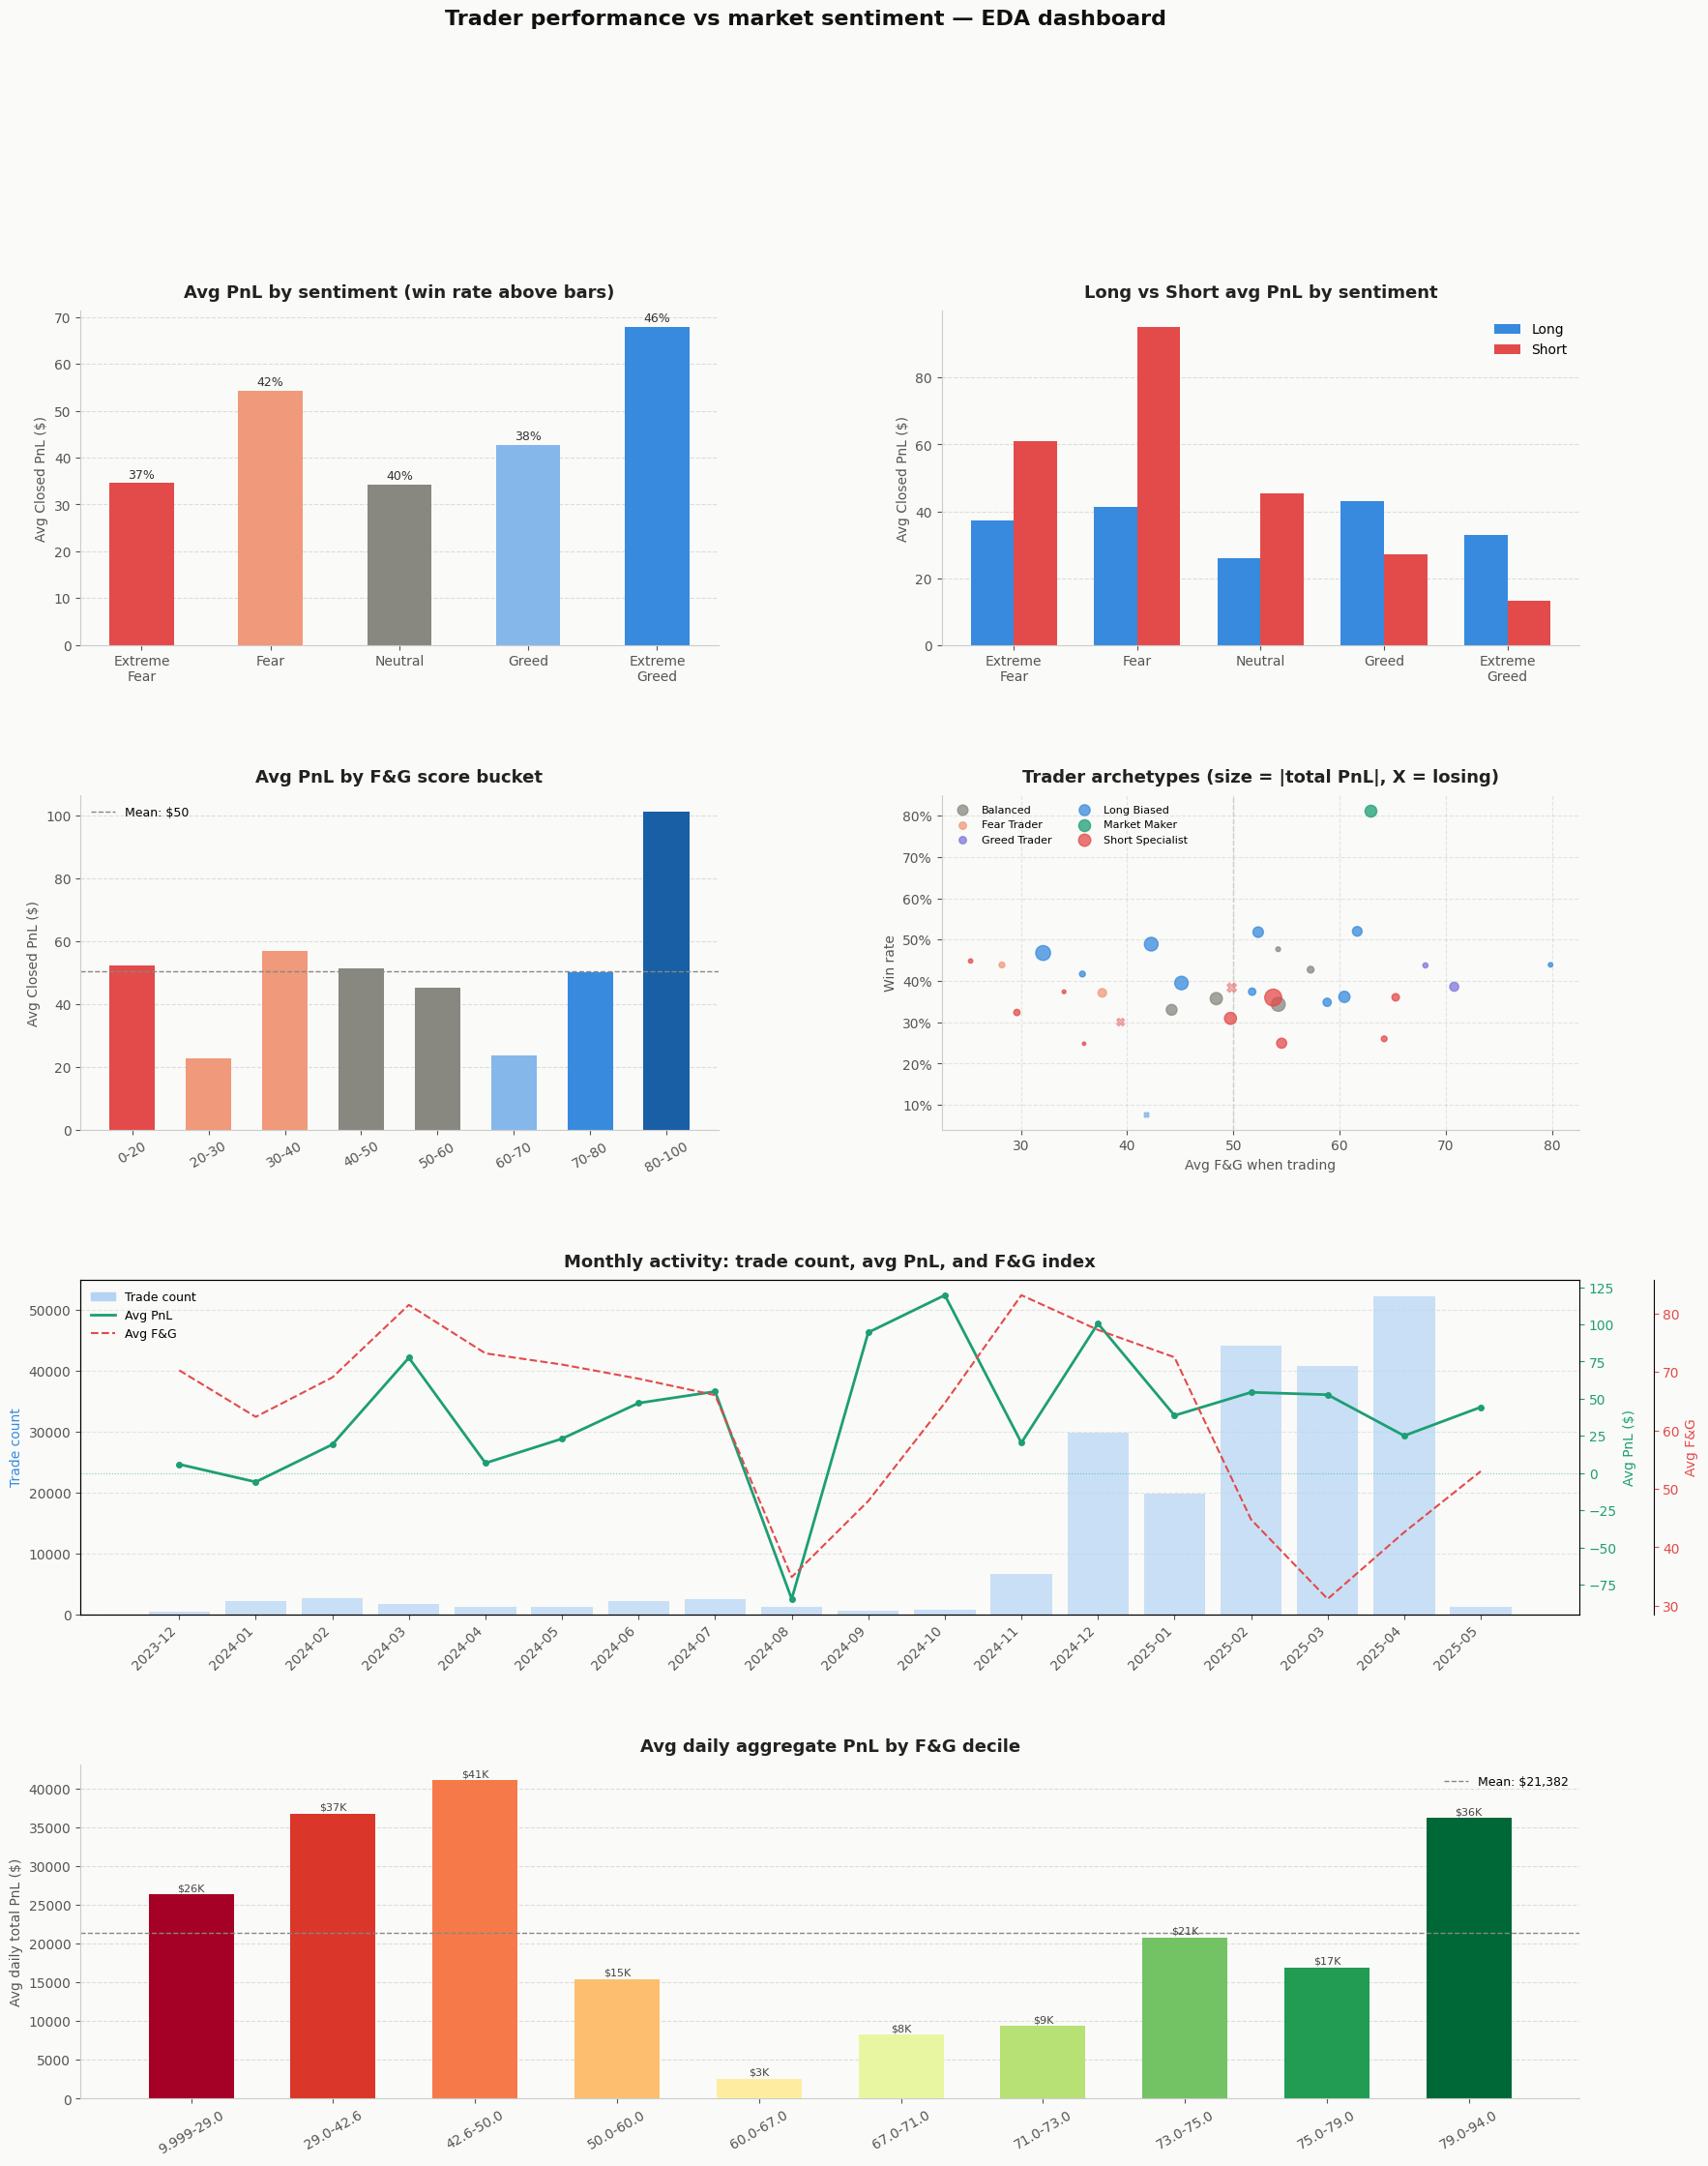

Saved: sentiment_trading_dashboard.png


In [69]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Load & prep
fg = pd.read_csv('fear_greed_index.csv')
hd = pd.read_csv('historical_data.csv')
fg['date'] = pd.to_datetime(fg['date'])
hd['date'] = pd.to_datetime(hd['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.normalize()
df = hd.merge(fg[['date','value','classification']], on='date', how='left')
df['is_win'] = df['Closed PnL'] > 0
direction_map = {'Open Long':'Long','Close Long':'Long','Open Short':'Short',
                 'Close Short':'Short','Long > Short':'Short','Short > Long':'Long'}
df['position_type'] = df['Direction'].map(direction_map)
df['month'] = df['date'].dt.to_period('M')
df['fg_bucket'] = pd.cut(df['value'],
    bins=[0,20,30,40,50,60,70,80,100],
    labels=['0-20','20-30','30-40','40-50','50-60','60-70','70-80','80-100'])

SENT_ORDER = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
SENT_COLORS = ['#E24B4A','#F0997B','#888780','#85B7EB','#378ADD']
SENT_MAP = dict(zip(SENT_ORDER, SENT_COLORS))

# Summary tables
sent_summary = df.groupby('classification').agg(
    avg_pnl=('Closed PnL','mean'),
    win_rate=('is_win','mean'),
    trade_count=('Closed PnL','count'),
    avg_size=('Size USD','mean')
).reindex(SENT_ORDER)

ls_sent = df[df['position_type'].isin(['Long','Short'])].groupby(
    ['classification','position_type'])['Closed PnL'].mean().unstack().reindex(SENT_ORDER)

bucket_pnl = df.groupby('fg_bucket', observed=True)['Closed PnL'].mean()

monthly = df.groupby('month').agg(
    trade_count=('Closed PnL','count'),
    avg_pnl=('Closed PnL','mean'),
    avg_fg=('value','mean')
).reset_index()
monthly['month_str'] = monthly['month'].astype(str)
monthly = monthly[monthly['trade_count'] > 100]  # drop sparse months

archetype_df = df[df['position_type'].isin(['Long','Short'])].groupby('Account').agg(
    total_pnl=('Closed PnL','sum'),
    win_rate=('is_win','mean'),
    trade_count=('Closed PnL','count'),
    long_ratio=('position_type', lambda x: (x=='Long').mean()),
    avg_fg=('value','mean')
)
def label(row):
    if row['win_rate'] > 0.7:      return 'Market Maker'
    elif row['long_ratio'] < 0.3:  return 'Short Specialist'
    elif row['long_ratio'] > 0.7:  return 'Long Biased'
    elif row['avg_fg'] < 40:       return 'Fear Trader'
    elif row['avg_fg'] > 60:       return 'Greed Trader'
    else:                          return 'Balanced'
archetype_df['archetype'] = archetype_df.apply(label, axis=1)
ARCH_COLORS = {
    'Short Specialist': '#E24B4A',
    'Long Biased':      '#378ADD',
    'Market Maker':     '#1D9E75',
    'Balanced':         '#888780',
    'Fear Trader':      '#F0997B',
    'Greed Trader':     '#7F77DD',
}

daily2 = df.groupby('date').agg(
    total_pnl=('Closed PnL','sum'),
    fg_value=('value','first')
).reset_index()
daily2['fg_decile'] = pd.qcut(daily2['fg_value'], q=10, duplicates='drop')
decile_pnl = daily2.groupby('fg_decile', observed=True)['total_pnl'].mean()
decile_labels = [str(i.left)+'-'+str(i.right) for i in decile_pnl.index]

# Figure Layout
fig = plt.figure(figsize=(20, 24), facecolor='#FAFAF8')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[2, :])
ax6 = fig.add_subplot(gs[3, :])

def style_ax(ax, title):
    ax.set_facecolor('#FAFAF8')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#555555', labelsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold', color='#222222', pad=10)

# Chart 1: Avg PnL & win rate by sentiment
x = np.arange(len(SENT_ORDER))
bars = ax1.bar(x, sent_summary['avg_pnl'], color=SENT_COLORS, width=0.5, zorder=2)
ax1.set_xticks(x)
ax1.set_xticklabels([s.replace(' ','\n') for s in SENT_ORDER], fontsize=9)
ax1.set_ylabel('Avg Closed PnL ($)', fontsize=10, color='#555555')
ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
for bar, wr in zip(bars, sent_summary['win_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{wr:.0%}', ha='center', va='bottom', fontsize=9, color='#333333')
style_ax(ax1, 'Avg PnL by sentiment (win rate above bars)')

# Chart 2: Long vs Short PnL by sentiment
w = 0.35
xi = np.arange(len(SENT_ORDER))
ax2.bar(xi - w/2, ls_sent['Long'],  width=w, label='Long',  color='#378ADD', zorder=2)
ax2.bar(xi + w/2, ls_sent['Short'], width=w, label='Short', color='#E24B4A', zorder=2)
ax2.set_xticks(xi)
ax2.set_xticklabels([s.replace(' ','\n') for s in SENT_ORDER], fontsize=9)
ax2.set_ylabel('Avg Closed PnL ($)', fontsize=10, color='#555555')
ax2.legend(fontsize=10, framealpha=0)
ax2.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
style_ax(ax2, 'Long vs Short avg PnL by sentiment')

# Chart 3: F&G bucket PnL
bucket_colors = ['#E24B4A','#F0997B','#F0997B','#888780','#888780','#85B7EB','#378ADD','#185FA5']
ax3.bar(range(len(bucket_pnl)), bucket_pnl.values, color=bucket_colors, width=0.6, zorder=2)
ax3.set_xticks(range(len(bucket_pnl)))
ax3.set_xticklabels(bucket_pnl.index.tolist(), fontsize=9, rotation=30)
ax3.set_ylabel('Avg Closed PnL ($)', fontsize=10, color='#555555')
ax3.axhline(bucket_pnl.mean(), color='#888780', linestyle='--', linewidth=1, label=f'Mean: ${bucket_pnl.mean():.0f}')
ax3.legend(fontsize=9, framealpha=0)
ax3.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
style_ax(ax3, 'Avg PnL by F&G score bucket')

# Chart 4: Trader archetype bubble chart
for arch, grp in archetype_df.groupby('archetype'):
    profitable = grp[grp['total_pnl'] > 0]
    losing = grp[grp['total_pnl'] <= 0]
    color = ARCH_COLORS.get(arch, '#888780')
    size = np.sqrt(np.abs(profitable['total_pnl'])) / 8
    ax4.scatter(profitable['avg_fg'], profitable['win_rate'],
                s=size, color=color, alpha=0.75, label=arch, zorder=3)
    if len(losing):
        size_l = np.sqrt(np.abs(losing['total_pnl'])) / 8
        ax4.scatter(losing['avg_fg'], losing['win_rate'],
                    s=size_l, color=color, alpha=0.4, marker='X', zorder=3)
ax4.axvline(50, color='#CCCCCC', linestyle='--', linewidth=1)
ax4.set_xlabel('Avg F&G when trading', fontsize=10, color='#555555')
ax4.set_ylabel('Win rate', fontsize=10, color='#555555')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax4.legend(fontsize=8, framealpha=0, ncol=2)
ax4.grid(linestyle='--', alpha=0.3, zorder=1)
style_ax(ax4, 'Trader archetypes (size = |total PnL|, X = losing)')

# Chart 5: Monthly trade volume + avg PnL + F&G line
ax5b = ax5.twinx()
ax5c = ax5.twinx()
ax5c.spines['right'].set_position(('outward', 55))

idx = range(len(monthly))
bars5 = ax5.bar(idx, monthly['trade_count'], color='#B5D4F4', alpha=0.7, zorder=2, label='Trade count')
ax5b.plot(idx, monthly['avg_pnl'], color='#1D9E75', linewidth=2, marker='o', markersize=4, zorder=3, label='Avg PnL')
ax5b.axhline(0, color='#1D9E75', linestyle=':', linewidth=0.8, alpha=0.5)
ax5c.plot(idx, monthly['avg_fg'], color='#E24B4A', linewidth=1.5, linestyle='--', zorder=3, label='Avg F&G')

ax5.set_xticks(idx)
ax5.set_xticklabels(monthly['month_str'], rotation=45, ha='right', fontsize=9)
ax5.set_ylabel('Trade count', fontsize=10, color='#378ADD')
ax5b.set_ylabel('Avg PnL ($)', fontsize=10, color='#1D9E75')
ax5c.set_ylabel('Avg F&G', fontsize=10, color='#E24B4A')
ax5.tick_params(axis='y', colors='#378ADD')
ax5b.tick_params(axis='y', colors='#1D9E75')
ax5c.tick_params(axis='y', colors='#E24B4A')
ax5.grid(axis='y', linestyle='--', alpha=0.3, zorder=1)

lines = [mpatches.Patch(color='#B5D4F4', label='Trade count'),
         Line2D([0],[0], color='#1D9E75', linewidth=2, label='Avg PnL'),
         Line2D([0],[0], color='#E24B4A', linewidth=1.5, linestyle='--', label='Avg F&G')]
ax5.legend(handles=lines, fontsize=9, framealpha=0, loc='upper left')
style_ax(ax5, 'Monthly activity: trade count, avg PnL, and F&G index')

# Chart 6: Daily PnL by F&G decile
cmap_vals = np.linspace(0, 1, len(decile_pnl))
colors6 = plt.cm.RdYlGn(cmap_vals)
bars6 = ax6.bar(range(len(decile_pnl)), decile_pnl.values, color=colors6, width=0.6, zorder=2)
ax6.set_xticks(range(len(decile_pnl)))
ax6.set_xticklabels(decile_labels, fontsize=9, rotation=30)
ax6.set_ylabel('Avg daily total PnL ($)', fontsize=10, color='#555555')
ax6.axhline(decile_pnl.mean(), color='#888780', linestyle='--', linewidth=1,
            label=f'Mean: ${decile_pnl.mean():,.0f}')
for bar, val in zip(bars6, decile_pnl.values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'${val/1000:.0f}K', ha='center', va='bottom', fontsize=8, color='#444444')
ax6.legend(fontsize=9, framealpha=0)
ax6.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
style_ax(ax6, 'Avg daily aggregate PnL by F&G decile')

fig.suptitle('Trader performance vs market sentiment — EDA dashboard',
             fontsize=16, fontweight='bold', color='#111111', y=1.01)

plt.savefig('sentiment_trading_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#FAFAF8')
plt.show()
print("Saved: sentiment_trading_dashboard.png")

## 10. Key takeaways

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Extreme Greed produces the highest avg PnL ($67) and win rate (46%) | Don't exit positions prematurely during euphoria |
| 2 | Shorts outperform longs in every sentiment regime except Greed | Majority of traders are over-exposed to long positions relative to what the data supports |
| 3 | F&G score 60–67 is a dead zone — daily PnL collapses to ~$2.5K | Reduce sizing or sit out during mid-greed transitions |
| 4 | Stable sentiment days (F&G change < 5 pts) produce 2.4x the PnL of rising-sentiment days | Momentum shifts are harder to trade than stable regimes |
| 5 | Two profitable traders with opposite strategies coexist — one Fear-specialist, one Greed-specialist | Sentiment-conditional strategy switching is a valid and proven approach |
| 6 | The 81% win rate trader is a market maker, not a directional predictor | High win rate alone is not a signal to copy — check the mechanism |
| 7 | TRUMP and FARTCOIN cost the cohort $465K combined | Meme coin exposure during sentiment extremes carries asymmetric downside |
| 8 | One trader is fee-insolvent despite positive gross PnL | Net PnL after fees is the only metric that matters for high-frequency strategies |